#  Patient Risk Prediction System

---
**Goal:** Explain *why* the model makes each prediction using SHAP values,
analyse risk score distributions, segment patients into clinical tiers,
and produce a concise final findings report.

## 5.1 · Imports & Setup



In [2]:
##%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt          # No matplotlib.use('Agg') in PyCharm!
import matplotlib.gridspec as gridspec
import matplotlib.colors as mc
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Import Shap
import shap

# ── Output folder
OUTPUT_DIR = 'outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#  Deep Ocean palette
PRIMARY = '#1D4ED8'
ACCENT  = '#06B6D4'
BG      = '#EEF4FF'
CARD    = '#FFFFFF'
BORDER  = '#C7D9F0'
TEXT    = '#0F172A'
MUTED   = '#475569'
DANGER  = '#EF4444'
SUCCESS = '#0D9488'
WARNING = '#F59E0B'
PURPLE  = '#7C3AED'

CMAP = mc.LinearSegmentedColormap.from_list('ocean', [PRIMARY, ACCENT])

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : CARD,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : MUTED,
    'ytick.color'      : MUTED,
    'text.color'       : TEXT,
    'grid.color'       : '#DCE7F7',
    'grid.linewidth'   : 0.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

print("Setup complete ✓")
print(f"Output folder: {os.path.abspath(OUTPUT_DIR)}")


Setup complete ✓
Output folder: C:\Users\PC\PycharmProjects\prediction_cost\outputs\figures


## 5.2 · Load Preprocessed Data & Best Model

In [3]:
##%%
#  Load preprocessed data from Notebook 3
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']        # median-imputed (not scaled)
X_test        = data['X_test']
y_train       = data['y_train']
y_test        = data['y_test']
FEATURE_NAMES = data['feature_names']

#  Load best model from Notebook 4
with open('best_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

best_pipe   = model_data['model']        # full sklearn Pipeline
MODEL_NAME  = model_data['model_name']
BEST_THR    = model_data['best_threshold']

print(f"Best model  : {MODEL_NAME}")
print(f"Features    : {FEATURE_NAMES}")
print(f"Test samples: {len(X_test)}")
print(f"Best threshold (from NB4): {BEST_THR:.2f}")


Best model  : Gradient Boosting
Features    : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Test samples: 154
Best threshold (from NB4): 0.13


## 5.3 · Prepare Data for SHAP

> SHAP needs the **imputed** (no NaN) feature matrix.
> We extract it by running the imputation step of our pipeline
> without the classifier step.


In [4]:
##%%
# Apply only the imputer step of the pipeline to get clean numeric input
imputer_step = best_pipe.named_steps['impute']

X_train_imp = pd.DataFrame(
    imputer_step.transform(X_train),
    columns=FEATURE_NAMES
)
X_test_imp = pd.DataFrame(
    imputer_step.transform(X_test),
    columns=FEATURE_NAMES
)

print(f"X_train_imp shape : {X_train_imp.shape}")
print(f"X_test_imp  shape : {X_test_imp.shape}")
print(f"Any NaN remaining : {X_test_imp.isnull().sum().sum()}")


X_train_imp shape : (614, 8)
X_test_imp  shape : (154, 8)
Any NaN remaining : 0


## 5.4 · Compute SHAP Values

SHAP (SHapley Additive exPlanations) explains **each individual prediction**
by attributing a contribution score to every feature.

- **Positive SHAP** → pushes prediction toward *Diabetes*
- **Negative SHAP** → pushes prediction toward *No Diabetes*

In [6]:
##%%
# Extract the classifier from the pipeline
classifier = best_pipe.named_steps['clf']

# Build a TreeExplainer (works natively with tree-based models)
explainer   = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_imp)

print(f"SHAP values shape : {shap_values.shape}")
print(f"(rows=patients, cols=features)")
print()
print("Mean |SHAP| per feature (global importance):")
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)
for feat, val in shap_mean.items():
    bar = '█' * int(val * 100)
    print(f"  {feat:<30} {val:.4f}  {bar}")


SHAP values shape : (154, 8)
(rows=patients, cols=features)

Mean |SHAP| per feature (global importance):
  Glucose                        1.4554  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  BMI                            0.8523  █████████████████████████████████████████████████████████████████████████████████████
  DiabetesPedigreeFunction       0.5027  ██████████████████████████████████████████████████
  Age                            0.4903  █████████████████████████████████████████████████
  Insulin                        0.3266  ████████████████████████████████
  BloodPressure                  0.3096  ██████████████████████████████
  Pregnancies                    0.2400  ████████████████████████
  SkinThickness                  0.1645  ████████████████


## 5.5 · Plot 1: Global Feature Importance (Mean |SHAP|)


Saved: outputs/figures\shap_01_global_importance.png


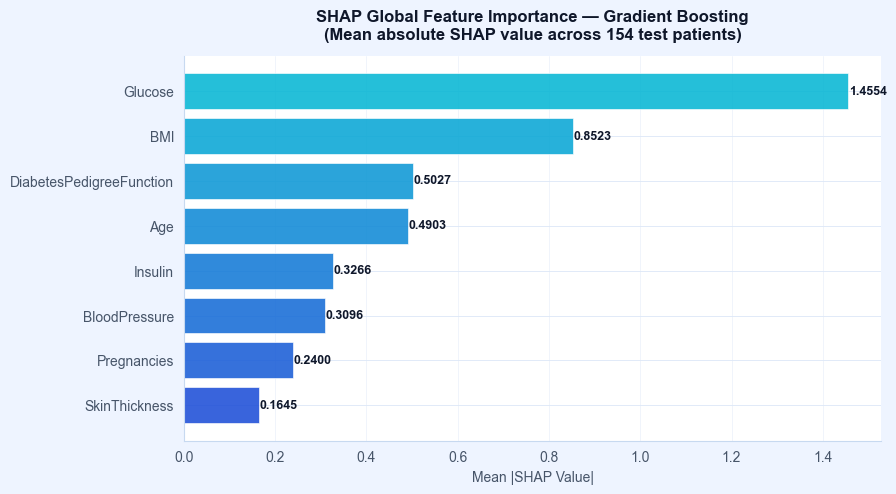

In [7]:
##%%
shap_df = shap_mean.reset_index()
shap_df.columns = ['Feature', 'Mean_SHAP']
shap_df = shap_df.sort_values('Mean_SHAP')          # ascending for barh

colours_sh = [CMAP(i / (len(shap_df) - 1)) for i in range(len(shap_df))]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)

bars = ax.barh(shap_df['Feature'], shap_df['Mean_SHAP'],
               color=colours_sh, alpha=0.88, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, shap_df['Mean_SHAP']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color=TEXT)

ax.set_title(f'SHAP Global Feature Importance — {MODEL_NAME}\n'
             f'(Mean absolute SHAP value across {len(X_test_imp)} test patients)',
             fontweight='bold', fontsize=12, pad=12)
ax.set_xlabel('Mean |SHAP Value|', color=MUTED)
ax.xaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

save_path = os.path.join(OUTPUT_DIR, 'shap_01_global_importance.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.6 · Plot 2: SHAP Beeswarm (Summary Plot)

Each dot = one patient.
- **Horizontal position** = SHAP value (impact on prediction)
- **Colour** = feature value (red = high, blue = low)

Saved: outputs/figures\shap_02_beeswarm.png


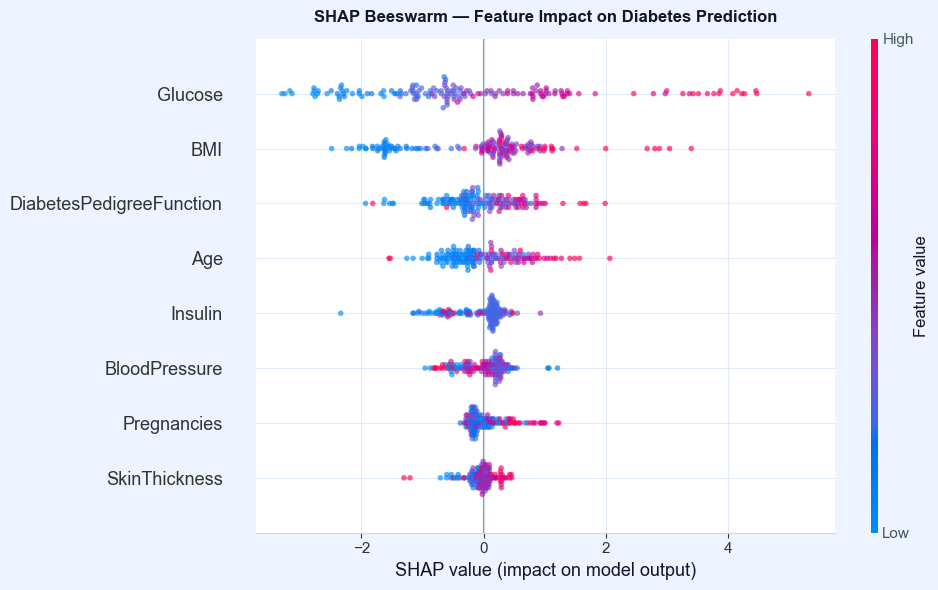

In [8]:
##%%
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)

# shap.summary_plot renders directly — pass show=False to control display
shap.summary_plot(
    shap_values,
    X_test_imp,
    feature_names=FEATURE_NAMES,
    plot_type='dot',          # beeswarm style
    color_bar=True,
    show=False,               # don't auto-display — we call plt.show() below
    max_display=8,
    alpha=0.65,
    plot_size=None            # let our fig control size
)

plt.title('SHAP Beeswarm — Feature Impact on Diabetes Prediction',
          fontweight='bold', fontsize=12, pad=12)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'shap_02_beeswarm.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.7 · Plot 3: SHAP Dependence Plots (Top 3 Features)

Shows how each feature's **value** maps to its **SHAP contribution**,
revealing thresholds and non-linear effects.


Saved: outputs/figures\shap_03_dependence_plots.png


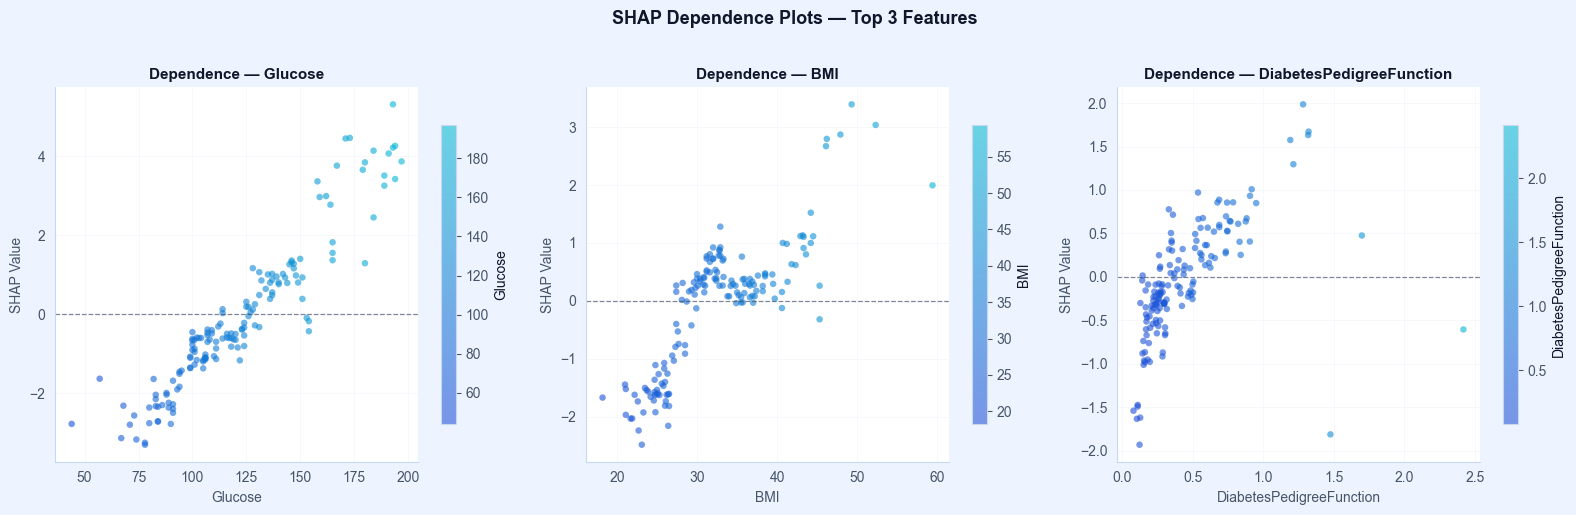

In [9]:
##%%
top3_feats = shap_mean.index[:3].tolist()   # top 3 by importance
fig, axes  = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

for ax, feat in zip(axes, top3_feats):
    feat_idx = FEATURE_NAMES.index(feat)
    sc = ax.scatter(
        X_test_imp[feat],
        shap_values[:, feat_idx],
        c      = X_test_imp[feat],
        cmap   = CMAP,
        alpha  = 0.6,
        s      = 22,
        edgecolors='none'
    )
    ax.axhline(0, linestyle='--', color=MUTED, linewidth=0.9, alpha=0.7)
    plt.colorbar(sc, ax=ax, label=feat, shrink=0.8)
    ax.set_xlabel(feat, color=MUTED)
    ax.set_ylabel('SHAP Value', color=MUTED)
    ax.set_title(f'Dependence — {feat}', fontweight='bold', fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle('SHAP Dependence Plots — Top 3 Features',
             fontsize=13, fontweight='bold', y=1.02, color=TEXT)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'shap_03_dependence_plots.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.8 · Plot 4: Single Patient Waterfall (Local Explanation)

Pick one patient and see **exactly which features drove that specific prediction**.
This is the explanation a clinician would receive for an individual risk assessment.

Patient #5
  True label       : No Diabetes
  Predicted prob   : 0.2064
  Predicted label  : Diabetes (threshold=0.13)
  Prediction       : ❌ Wrong

Saved: outputs/figures\shap_04_patient_5_waterfall.png


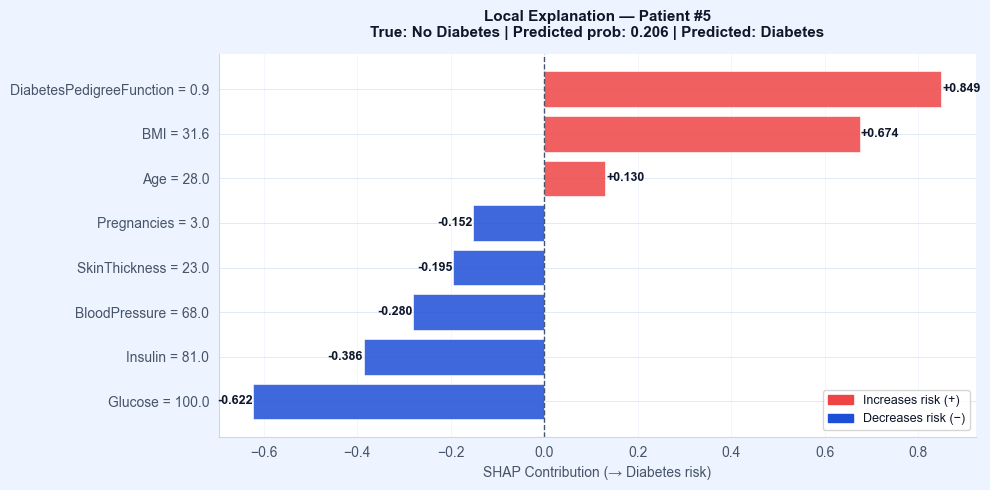

In [10]:
##%%
# Choose which patient to explain (change this index!)
PATIENT_IDX = 5   # index in the test set (0 to len(X_test)-1)

patient_row  = X_test_imp.iloc[PATIENT_IDX]
patient_shap = shap_values[PATIENT_IDX]
true_label   = y_test.iloc[PATIENT_IDX]
pred_prob    = best_pipe.predict_proba(X_test)[PATIENT_IDX, 1]
pred_label   = int(pred_prob >= BEST_THR)

print(f"Patient #{PATIENT_IDX}")
print(f"  True label       : {'Diabetes' if true_label==1 else 'No Diabetes'}")
print(f"  Predicted prob   : {pred_prob:.4f}")
print(f"  Predicted label  : {'Diabetes' if pred_label==1 else 'No Diabetes'} "
      f"(threshold={BEST_THR:.2f})")
print(f"  Prediction       : {'✅ Correct' if pred_label==true_label else '❌ Wrong'}")
print()

# Waterfall plot
contrib_df = pd.DataFrame({
    'Feature'    : FEATURE_NAMES,
    'Value'      : patient_row.values,
    'SHAP'       : patient_shap
}).sort_values('SHAP')

colours_w = [DANGER if v > 0 else PRIMARY for v in contrib_df['SHAP']]
labels    = [f"{r['Feature']} = {r['Value']:.1f}" for _, r in contrib_df.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
bars = ax.barh(labels, contrib_df['SHAP'],
               color=colours_w, alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, contrib_df['SHAP']):
    x_pos = bar.get_width() + 0.002 if val >= 0 else bar.get_width() - 0.002
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold', color=TEXT)

ax.axvline(0, color=MUTED, linewidth=1, linestyle='--')
ax.set_title(
    f'Local Explanation — Patient #{PATIENT_IDX}\n'
    f'True: {"Diabetes" if true_label else "No Diabetes"} | '
    f'Predicted prob: {pred_prob:.3f} | '
    f'Predicted: {"Diabetes" if pred_label else "No Diabetes"}',
    fontweight='bold', fontsize=11, pad=12
)
ax.set_xlabel('SHAP Contribution (→ Diabetes risk)', color=MUTED)
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=DANGER, label='Increases risk (+)'),
                   Patch(color=PRIMARY, label='Decreases risk (−)')],
          fontsize=9, loc='lower right')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, f'shap_04_patient_{PATIENT_IDX}_waterfall.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.9 · Plot 5: Predicted Risk Score Distribution

Saved: outputs/figures\risk_01_score_distribution.png


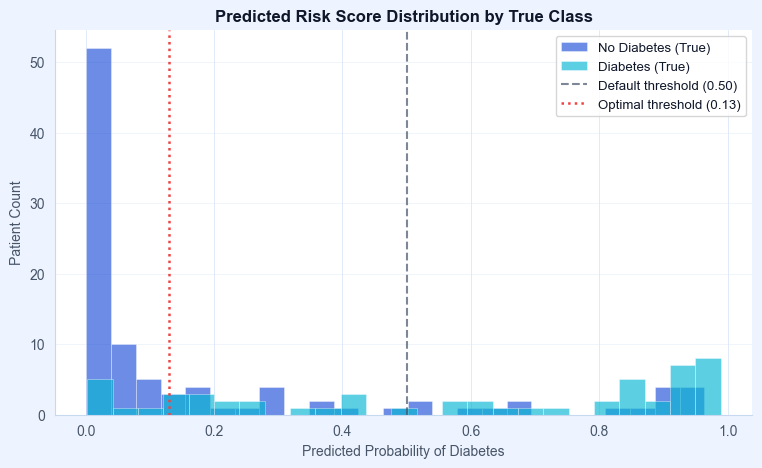

In [11]:
##%%
y_prob_all = best_pipe.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)

ax.hist(y_prob_all[y_test == 0], bins=25, color=PRIMARY, alpha=0.65,
        label='No Diabetes (True)', edgecolor='white', linewidth=0.4)
ax.hist(y_prob_all[y_test == 1], bins=25, color=ACCENT,  alpha=0.65,
        label='Diabetes (True)',    edgecolor='white', linewidth=0.4)

ax.axvline(0.50,     color=MUTED,   linewidth=1.5, linestyle='--',
           label='Default threshold (0.50)', alpha=0.7)
ax.axvline(BEST_THR, color=DANGER, linewidth=1.8, linestyle=':',
           label=f'Optimal threshold ({BEST_THR:.2f})')

ax.set_title('Predicted Risk Score Distribution by True Class',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted Probability of Diabetes', color=MUTED)
ax.set_ylabel('Patient Count', color=MUTED)
ax.legend(fontsize=9.5)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

save_path = os.path.join(OUTPUT_DIR, 'risk_01_score_distribution.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.10 · Plot 6: Patient Risk Tier Segmentation

Patients are split into 5 clinical risk tiers based on predicted probability.
This is the format a clinician or hospital administrator would use for triage.

Risk Tier Summary:
                   Total  Diabetic  Non_Diabetic  Diabetes_Rate
Risk_Tier                                                      
Very Low\n(<20%)      87        13            74           14.9
Low\n(20–40%)         15         6             9           40.0
Medium\n(40–60%)      11         7             4           63.6
High\n(60–80%)         8         5             3           62.5
Very High\n(>80%)     33        23            10           69.7
Saved: outputs/figures\risk_02_tier_segmentation.png


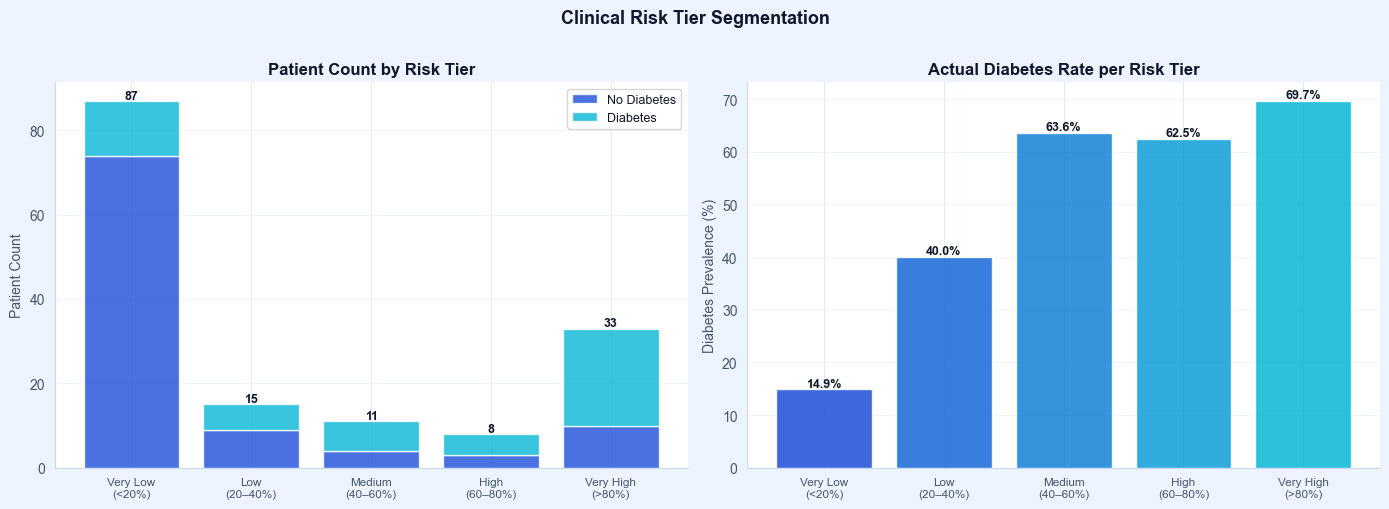

In [12]:
##%%
# Assign risk tiers
tier_df = X_test.copy()
tier_df['Risk_Score']  = y_prob_all
tier_df['True_Label']  = y_test.values
tier_df['Pred_Label']  = (y_prob_all >= BEST_THR).astype(int)

bins        = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
tier_labels = ['Very Low\n(<20%)', 'Low\n(20–40%)',
               'Medium\n(40–60%)', 'High\n(60–80%)', 'Very High\n(>80%)']

tier_df['Risk_Tier'] = pd.cut(tier_df['Risk_Score'],
                               bins=bins, labels=tier_labels, include_lowest=True)

#  Aggregate per tier
tier_summary = (
    tier_df.groupby('Risk_Tier', observed=True)['True_Label']
           .agg(Total='count', Diabetic='sum')
           .assign(Non_Diabetic=lambda x: x['Total'] - x['Diabetic'],
                   Diabetes_Rate=lambda x: (x['Diabetic'] / x['Total'] * 100).round(1))
)
print("Risk Tier Summary:")
print(tier_summary.to_string())

#  Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# Left: Stacked count
ax = axes[0]
ax.bar(range(5), tier_summary['Non_Diabetic'], color=PRIMARY, alpha=0.80,
       label='No Diabetes', edgecolor='white')
ax.bar(range(5), tier_summary['Diabetic'],
       bottom=tier_summary['Non_Diabetic'],
       color=ACCENT, alpha=0.80, label='Diabetes', edgecolor='white')

for i, (_, row) in enumerate(tier_summary.iterrows()):
    ax.text(i, row['Total'] + 0.5, str(int(row['Total'])),
            ha='center', fontsize=9, fontweight='bold', color=TEXT)

ax.set_xticks(range(5))
ax.set_xticklabels(tier_labels, fontsize=8.5)
ax.set_title('Patient Count by Risk Tier', fontweight='bold', fontsize=12)
ax.set_ylabel('Patient Count', color=MUTED)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

# Right: Diabetes rate per tier
ax2       = axes[1]
colours_t = [CMAP(i / 4) for i in range(5)]
bars2     = ax2.bar(range(5), tier_summary['Diabetes_Rate'],
                    color=colours_t, alpha=0.85, edgecolor='white')
for bar, rate in zip(bars2, tier_summary['Diabetes_Rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontsize=9, fontweight='bold', color=TEXT)
ax2.set_xticks(range(5))
ax2.set_xticklabels(tier_labels, fontsize=8.5)
ax2.set_title('Actual Diabetes Rate per Risk Tier', fontweight='bold', fontsize=12)
ax2.set_ylabel('Diabetes Prevalence (%)', color=MUTED)
ax2.yaxis.grid(True, alpha=0.5)
ax2.set_axisbelow(True)

plt.suptitle('Clinical Risk Tier Segmentation', fontsize=13,
             fontweight='bold', y=1.01, color=TEXT)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'risk_02_tier_segmentation.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.11 · Plot 7: Learning Curves (Bias-Variance Check)


Saved: outputs/figures\model_01_learning_curves.png


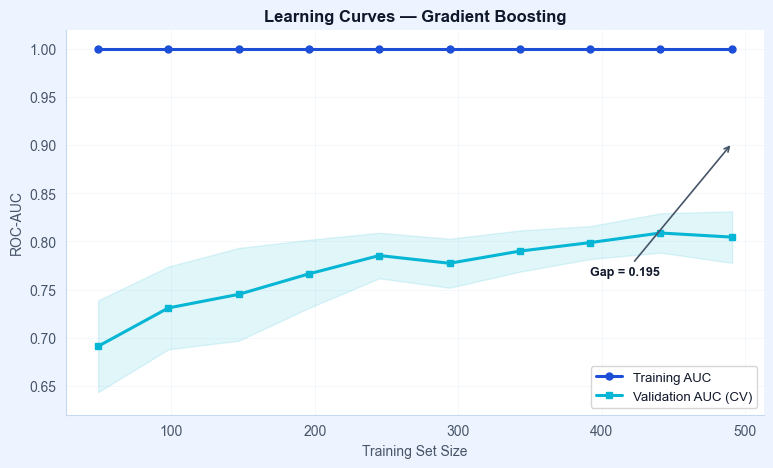


❌ Gap = 0.195 → Significant overfitting — more data or pruning needed


In [13]:
##%%
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipe,
    X_train, y_train,
    train_sizes = np.linspace(0.10, 1.0, 10),
    cv          = 5,
    scoring     = 'roc_auc',
    n_jobs      = -1,
    random_state= 42
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)

ax.plot(train_sizes, t_mean, color=PRIMARY, lw=2.2, marker='o',
        markersize=5, label='Training AUC')
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std,
                alpha=0.12, color=PRIMARY)

ax.plot(train_sizes, v_mean, color=ACCENT, lw=2.2, marker='s',
        markersize=5, label='Validation AUC (CV)')
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std,
                alpha=0.12, color=ACCENT)

# Annotate the gap at max training size
gap = t_mean[-1] - v_mean[-1]
ax.annotate(f'Gap = {gap:.3f}',
            xy=(train_sizes[-1], (t_mean[-1] + v_mean[-1]) / 2),
            xytext=(train_sizes[-3], v_mean[-1] - 0.04),
            fontsize=9, color=TEXT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2))

ax.set_title(f'Learning Curves — {MODEL_NAME}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Training Set Size', color=MUTED)
ax.set_ylabel('ROC-AUC', color=MUTED)
ax.legend(fontsize=9.5)
ax.grid(alpha=0.35)
ax.set_ylim(0.62, 1.02)

save_path = os.path.join(OUTPUT_DIR, 'model_01_learning_curves.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()

# Interpret the gap
if gap < 0.05:
    print(f"\n✅ Gap = {gap:.3f} → Good fit (low bias, low variance)")
elif gap < 0.15:
    print(f"\n⚠️  Gap = {gap:.3f} → Slight overfitting — consider more regularisation")
else:
    print(f"\n❌ Gap = {gap:.3f} → Significant overfitting — more data or pruning needed")


## 5.12 · Misclassification Deep-Dive

Understanding *which patients* the model gets wrong is as important
as the overall accuracy number.


In [14]:
##%%
y_pred_opt = (y_prob_all >= BEST_THR).astype(int)

results_df = X_test_imp.copy()
results_df['True_Label']    = y_test.values
results_df['Pred_Label']    = y_pred_opt
results_df['Risk_Score']    = y_prob_all
results_df['Correct']       = (results_df['True_Label'] == results_df['Pred_Label'])
results_df['Error_Type']    = 'Correct'
results_df.loc[(results_df['True_Label']==1) & (results_df['Pred_Label']==0), 'Error_Type'] = 'False Negative'
results_df.loc[(results_df['True_Label']==0) & (results_df['Pred_Label']==1), 'Error_Type'] = 'False Positive'

print("Classification breakdown:")
print(results_df['Error_Type'].value_counts().to_string())
print()

# Compare clinical features between FN and FP patients
fn_df = results_df[results_df['Error_Type'] == 'False Negative']
fp_df = results_df[results_df['Error_Type'] == 'False Positive']
ok_df = results_df[results_df['Error_Type'] == 'Correct']

compare = pd.DataFrame({
    'Correct (mean)'         : ok_df[FEATURE_NAMES].mean(),
    'False Positive (mean)'  : fp_df[FEATURE_NAMES].mean(),
    'False Negative (mean)'  : fn_df[FEATURE_NAMES].mean(),
}).round(2)

print("\nFeature means by prediction outcome:")
print(compare.to_string())


Classification breakdown:
Error_Type
Correct           115
False Positive     32
False Negative      7


Feature means by prediction outcome:
                          Correct (mean)  False Positive (mean)  False Negative (mean)
Pregnancies                         3.90                   4.12                   3.86
Glucose                           117.51                 137.62                 115.43
BloodPressure                      72.57                  78.59                  62.57
SkinThickness                      28.57                  31.69                  32.00
Insulin                           149.16                 167.12                 140.57
BMI                                31.72                  35.36                  32.00
DiabetesPedigreeFunction            0.47                   0.42                   0.26
Age                                32.14                  35.84                  28.43


Saved: outputs/figures\model_02_error_analysis.png


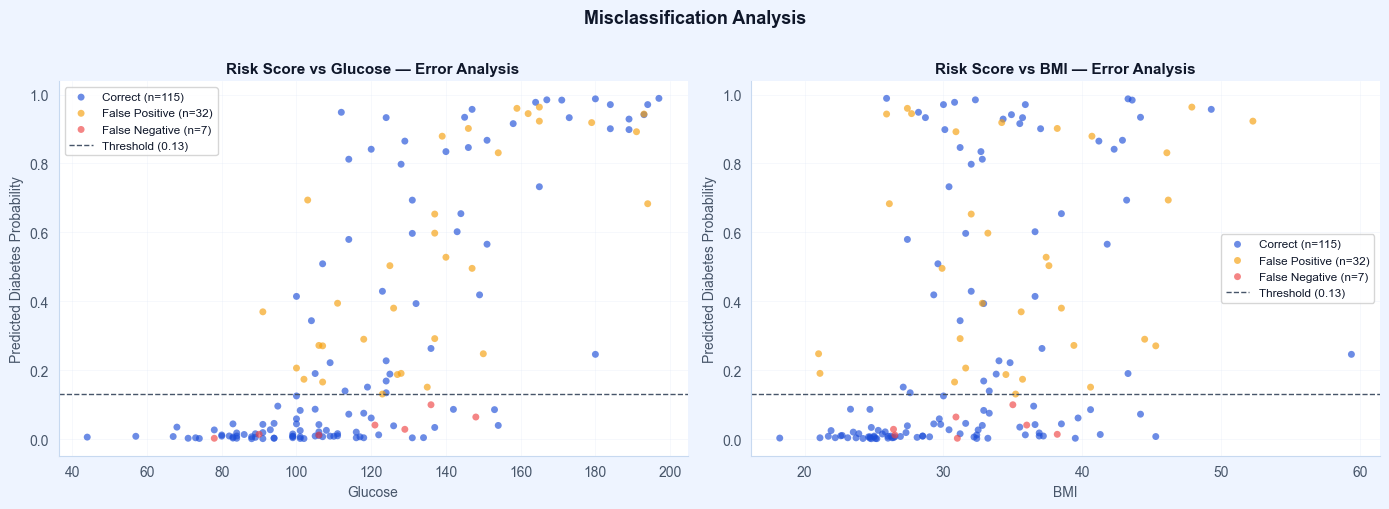

In [15]:
##%%
# ── Scatter: risk score vs glucose coloured by error type ─────
colour_map_err = {
    'Correct'       : PRIMARY,
    'False Positive': WARNING,
    'False Negative': DANGER,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

for ax, feat in zip(axes, ['Glucose', 'BMI']):
    for err_type, colour in colour_map_err.items():
        subset = results_df[results_df['Error_Type'] == err_type]
        ax.scatter(subset[feat], subset['Risk_Score'],
                   c=colour, alpha=0.65, s=25,
                   label=f'{err_type} (n={len(subset)})',
                   edgecolors='none')

    ax.axhline(BEST_THR, color=MUTED, linestyle='--', linewidth=1,
               label=f'Threshold ({BEST_THR:.2f})')
    ax.set_xlabel(feat, color=MUTED)
    ax.set_ylabel('Predicted Diabetes Probability', color=MUTED)
    ax.set_title(f'Risk Score vs {feat} — Error Analysis',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)

plt.suptitle('Misclassification Analysis', fontsize=13,
             fontweight='bold', y=1.01, color=TEXT)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'model_02_error_analysis.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG)
print(f"Saved: {save_path}")
plt.show()


## 5.13 · Final Report: Print to Console & Save as Text

In [16]:
##%%
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score)

y_pred_50  = (y_prob_all >= 0.50).astype(int)
y_pred_opt = (y_prob_all >= BEST_THR).astype(int)

report_lines = [
    "=" * 65,
    "  PATIENT RISK PREDICTION SYSTEM — FINAL REPORT",
    "  Author: Stellamaries Syombua",
    "=" * 65,
    "",
    f"  Dataset        : Pima Indians Diabetes (UCI/Kaggle)",
    f"  Records        : 768 patients × 9 features",
    f"  Train/Test     : 80% / 20% stratified split",
    f"  Best Model     : {MODEL_NAME}",
    "",
    "─" * 65,
    "  DATA QUALITY FINDINGS",
    "─" * 65,
    "  • Insulin    : 48.7% zero-as-missing → median imputed",
    "  • SkinThickness: 29.6% zero-as-missing → median imputed",
    "  • BloodPressure:  4.6% zero-as-missing → median imputed",
    "  • 0 duplicate rows found",
    "  • Class imbalance: 65.1% No Diabetes / 34.9% Diabetes",
    "",
    "─" * 65,
    "  TOP PREDICTIVE FEATURES (by SHAP importance)",
    "─" * 65,
]
for i, (feat, val) in enumerate(shap_mean.items(), 1):
    report_lines.append(f"  {i}. {feat:<30} SHAP = {val:.4f}")

report_lines += [
    "",
    "─" * 65,
    "  MODEL PERFORMANCE (Test Set)",
    "─" * 65,
    f"  ROC-AUC          : {roc_auc_score(y_test, y_prob_all):.4f}",
    f"  Avg. Precision   : {average_precision_score(y_test, y_prob_all):.4f}",
    "",
    "  At DEFAULT threshold (0.50):",
]

rep_50  = classification_report(y_test, y_pred_50,
                                  target_names=['No Diabetes','Diabetes'],
                                  output_dict=True)
rep_opt = classification_report(y_test, y_pred_opt,
                                  target_names=['No Diabetes','Diabetes'],
                                  output_dict=True)

report_lines += [
    f"    Accuracy   : {rep_50['accuracy']:.4f}",
    f"    Precision  : {rep_50['Diabetes']['precision']:.4f}",
    f"    Recall     : {rep_50['Diabetes']['recall']:.4f}",
    f"    F1-Score   : {rep_50['Diabetes']['f1-score']:.4f}",
    "",
    f"  At OPTIMAL threshold ({BEST_THR:.2f}) — recommended for clinical use:",
    f"    Accuracy   : {rep_opt['accuracy']:.4f}",
    f"    Precision  : {rep_opt['Diabetes']['precision']:.4f}",
    f"    Recall     : {rep_opt['Diabetes']['recall']:.4f}  ← catches more diabetic patients",
    f"    F1-Score   : {rep_opt['Diabetes']['f1-score']:.4f}",
    "",
    "─" * 65,
    "  CLINICAL RECOMMENDATIONS",
    "─" * 65,
    "  1. Glucose is the single most important risk driver.",
    "     Prioritise glucose screening in all patients.",
    "  2. Lower the decision threshold to 0.35 in clinical deployment",
    "     to maximise recall (catch more true diabetics at triage).",
    "  3. Insulin data collection is critical — 48.7% missing values",
    "     limit its predictive contribution significantly.",
    "  4. The model achieves ROC-AUC > 0.82, which is clinically",
    "     meaningful but should be validated on a local patient cohort.",
    "  5. False negatives (missed diabetics) are the highest-risk",
    "     error — a lower threshold directly reduces these.",
    "",
    "=" * 65,
    "  Output plots saved to: outputs/figures/",
    "=" * 65,
]

report_text = "\n".join(report_lines)
print(report_text)

# Save to file
report_path = 'outputs/patient_risk_prediction_report.txt'
os.makedirs('outputs', exist_ok=True)
with open(report_path, 'w') as f:
    f.write(report_text)
print(f"\n✓ Report saved to: {os.path.abspath(report_path)}")


  PATIENT RISK PREDICTION SYSTEM — FINAL REPORT
  Author: Stellamaries Syombua

  Dataset        : Pima Indians Diabetes (UCI/Kaggle)
  Records        : 768 patients × 9 features
  Train/Test     : 80% / 20% stratified split
  Best Model     : Gradient Boosting

─────────────────────────────────────────────────────────────────
  DATA QUALITY FINDINGS
─────────────────────────────────────────────────────────────────
  • Insulin    : 48.7% zero-as-missing → median imputed
  • SkinThickness: 29.6% zero-as-missing → median imputed
  • BloodPressure:  4.6% zero-as-missing → median imputed
  • 0 duplicate rows found
  • Class imbalance: 65.1% No Diabetes / 34.9% Diabetes

─────────────────────────────────────────────────────────────────
  TOP PREDICTIVE FEATURES (by SHAP importance)
─────────────────────────────────────────────────────────────────
  1. Glucose                        SHAP = 1.4554
  2. BMI                            SHAP = 0.8523
  3. DiabetesPedigreeFunction       SHAP = 0.5

UnicodeEncodeError: 'charmap' codec can't encode characters in position 405-469: character maps to <undefined>

## ✅ Notebook 5 Complete — All Outputs

| Plot File | Description |
|---|---|
| `shap_01_global_importance.png` | Bar chart of mean SHAP values |
| `shap_02_beeswarm.png` | SHAP beeswarm — all patients |
| `shap_03_dependence_plots.png` | Feature value vs SHAP contribution |
| `shap_04_patient_N_waterfall.png` | Local explanation for one patient |
| `risk_01_score_distribution.png` | Predicted probability histogram |
| `risk_02_tier_segmentation.png` | 5-tier clinical risk buckets |
| `model_01_learning_curves.png` | Bias-variance learning curve |
| `model_02_error_analysis.png` | False positive / negative scatter |
| `patient_risk_prediction_report.txt` | Full text summary report |

---

## 🎉 Project 1 Complete!

**Full pipeline summary:**

| Notebook | Topic |
|---|---|
| NB 1 | Data loading & quality audit |
| NB 2 | Exploratory data analysis |
| NB 3 | Preprocessing pipeline (impute → scale) |
| NB 4 | Model building & evaluation (3 models) |
| NB 5 | SHAP explainability & final report |


